## Problema
Como practica, entrenar un Random Forest con mi dataset

No categorical columns found — skipping One-Hot Encoding.
Train size:      600 samples (60.0%)
Validation size: 200 samples (20.0%)
Test size:       200 samples (20.0%)

  TRAIN SET — Accuracy: 0.9983
              precision    recall  f1-score   support

       blues       1.00      1.00      1.00        60
   classical       1.00      1.00      1.00        60
     country       1.00      1.00      1.00        60
       disco       1.00      1.00      1.00        60
      hiphop       1.00      1.00      1.00        60
        jazz       1.00      1.00      1.00        60
       metal       0.98      1.00      0.99        60
         pop       1.00      1.00      1.00        60
      reggae       1.00      1.00      1.00        60
        rock       1.00      0.98      0.99        60

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


  VALIDATION SET — Accuracy: 0.7300
   

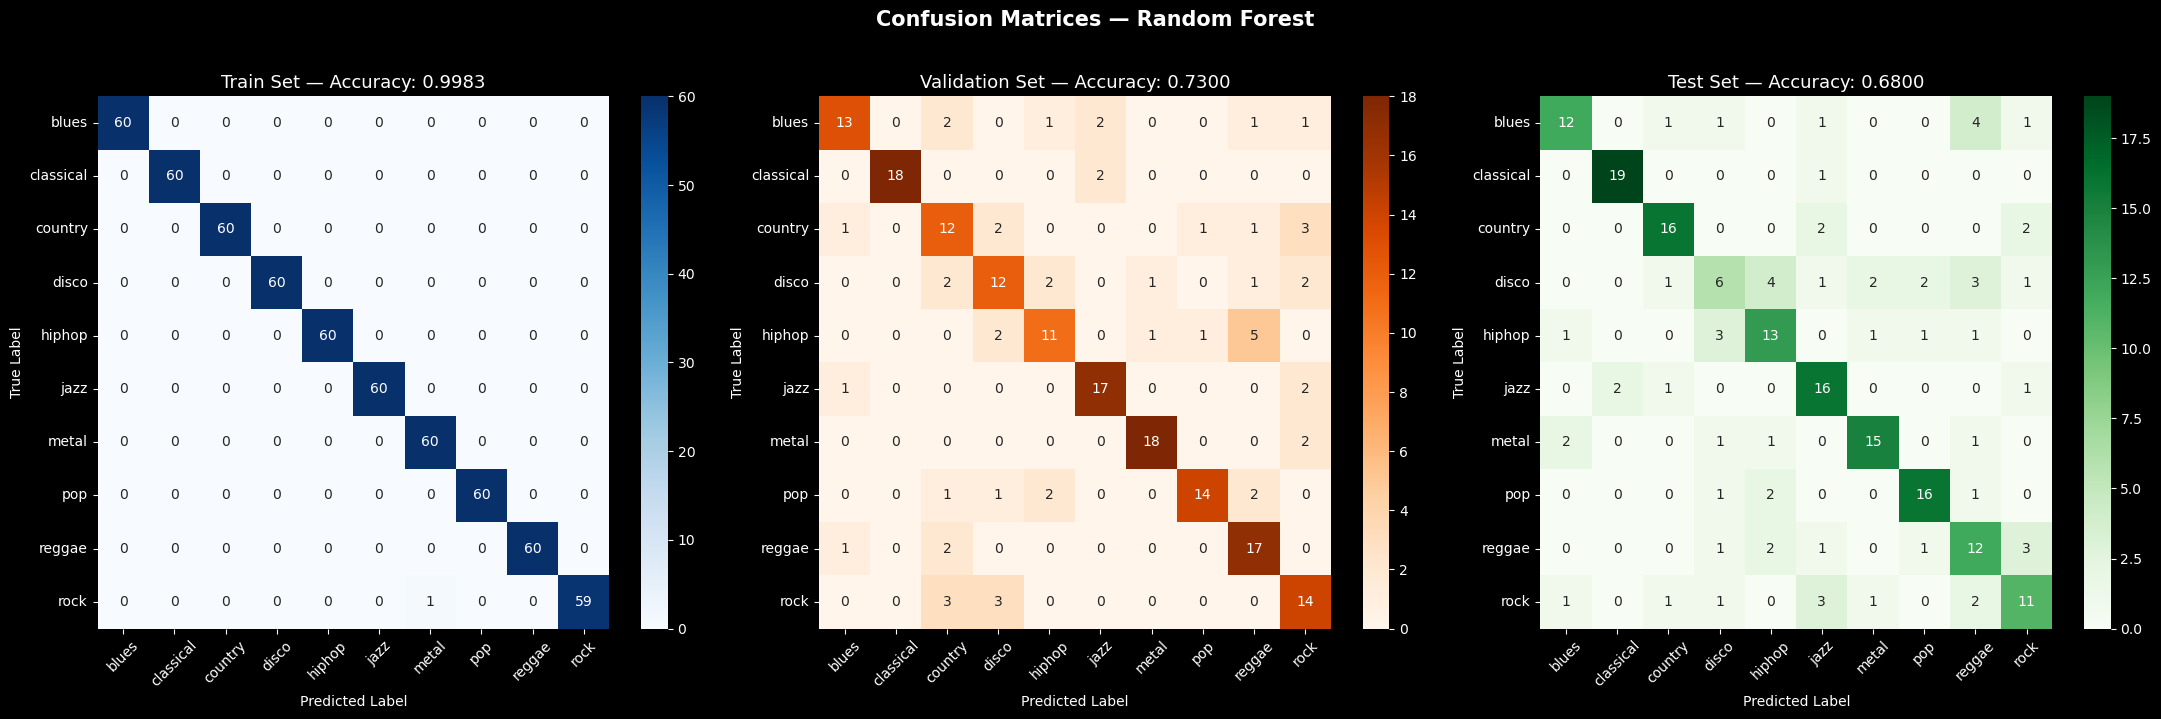

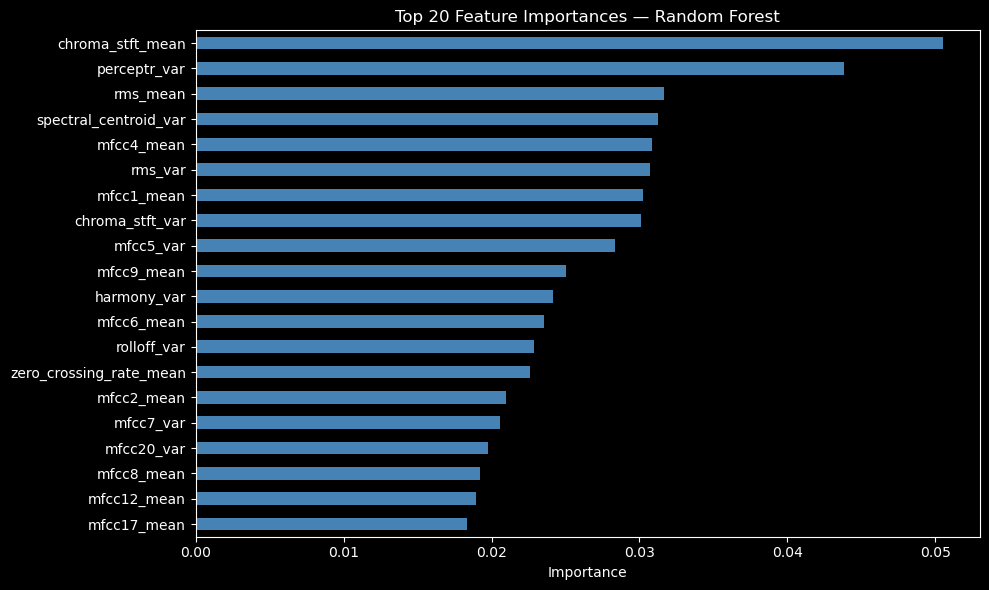

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# 1. LOAD & PREPROCESS (from your exploratory code)
# ─────────────────────────────────────────────
df = pd.read_csv("data/features_30_sec.csv")

# # Remove highly correlated features
corr_matrix = df.corr(numeric_only=True)
high_corr = corr_matrix.stack().reset_index()
high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']
high_corr = high_corr[
    (high_corr['Correlation'] > 0.9) & 
    (high_corr['Feature_1'] != high_corr['Feature_2'])
]

# Keep only one from each correlated pair (drop Feature_2 duplicates)
cols_to_drop = list(set(high_corr["Feature_2"].values))
df = df.drop(columns=cols_to_drop, errors='ignore')

# ─────────────────────────────────────────────
# 2. ENCODE TARGET
# ─────────────────────────────────────────────
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

# ─────────────────────────────────────────────
# 3. FEATURES & TARGET
# ─────────────────────────────────────────────
# Drop non-feature columns

X = df.drop(columns=["filename", "label", "label_encoded", "length"], errors='ignore')

# One-Hot Encoding for any remaining categorical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
if categorical_cols:
    print(f"Applying One-Hot Encoding to: {categorical_cols}")
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
else:
    print("No categorical columns found — skipping One-Hot Encoding.")

y = df["label_encoded"]

# ─────────────────────────────────────────────
# 4. SPLIT: 60% train | 20% val | 20% test
# ─────────────────────────────────────────────
# First split off 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Then split remaining 80% into 60% train + 20% val (0.25 * 0.80 = 0.20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Train size:      {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation size: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test size:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# ─────────────────────────────────────────────
# 5. STANDARDIZE (fit only on train, apply to val & test)
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ─────────────────────────────────────────────
# 6. TRAIN RANDOM FOREST
# ─────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

# ─────────────────────────────────────────────
# 7. EVALUATE
# ─────────────────────────────────────────────
def evaluate(model, X, y, split_name, label_encoder):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    print(f"\n{'='*40}")
    print(f"  {split_name} — Accuracy: {acc:.4f}")
    print('='*40)
    print(classification_report(y, preds, target_names=label_encoder.classes_))
    return preds

train_preds = evaluate(rf, X_train_scaled, y_train, "TRAIN SET",      le)
val_preds   = evaluate(rf, X_val_scaled,   y_val,   "VALIDATION SET", le)
test_preds  = evaluate(rf, X_test_scaled,  y_test,  "TEST SET",       le)

# ─────────────────────────────────────────────
# 8. CONFUSION MATRICES (train / val / test side by side)
# ─────────────────────────────────────────────
splits = [
    ("Train",      y_train, train_preds, "Blues"),
    ("Validation", y_val,   val_preds,   "Oranges"),
    ("Test",       y_test,  test_preds,  "Greens"),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (name, y_true, y_pred, cmap) in zip(axes, splits):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax
    )
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{name} Set — Accuracy: {acc:.4f}", fontsize=13)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle("Confusion Matrices — Random Forest", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/results/confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# 9. FEATURE IMPORTANCE (Top 20)
# ─────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 20 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("data/results/feature_importances.png", dpi=150)
plt.show()


  TRAIN SET — Accuracy: 0.9983
              precision    recall  f1-score   support

       blues       1.00      1.00      1.00        60
   classical       1.00      1.00      1.00        60
     country       1.00      1.00      1.00        60
       disco       1.00      1.00      1.00        60
      hiphop       1.00      1.00      1.00        60
        jazz       1.00      1.00      1.00        60
       metal       1.00      0.98      0.99        60
         pop       1.00      1.00      1.00        60
      reggae       1.00      1.00      1.00        60
        rock       0.98      1.00      0.99        60

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


  VALIDATION SET — Accuracy: 0.7300
              precision    recall  f1-score   support

       blues       0.92      0.55      0.69        20
   classical       0.95      0.90      0.92        20
     coun

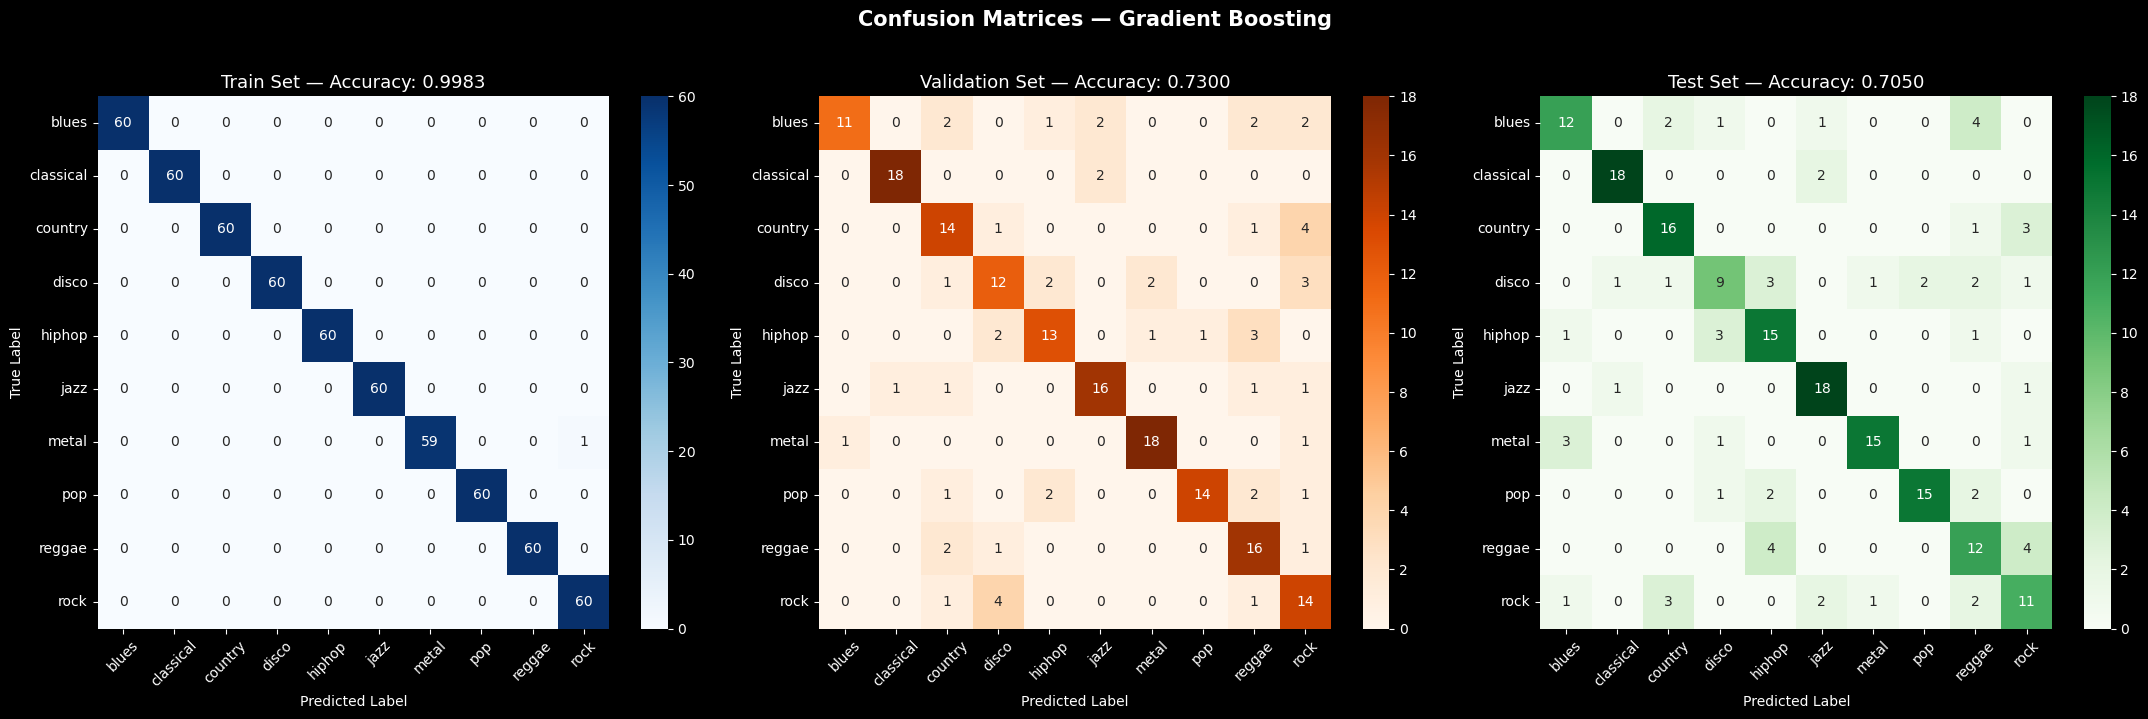


── Model Comparison (Validation Accuracy) ──
  Random Forest             0.7300
  Gradient Boosting         0.7300


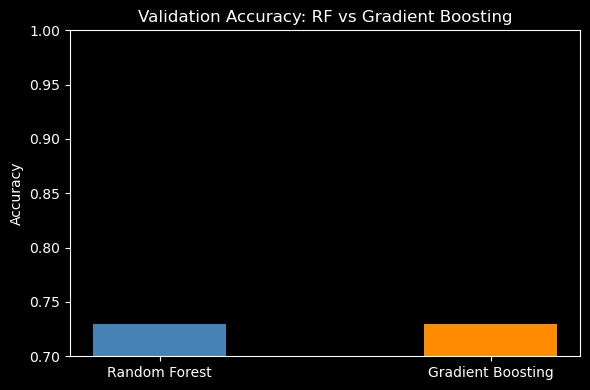

In [2]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

# ─────────────────────────────────────────────
# 6. TRAIN GRADIENT BOOSTING
# ─────────────────────────────────────────────
# GradientBoostingClassifier supports multiclass natively but can be slow.

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

gb = OneVsRestClassifier(
    GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=4,
        min_samples_leaf=2,
        subsample=0.8,           # stochastic GB — reduces overfitting
        max_features="sqrt",
        random_state=42
    ),
    n_jobs=-1                    # parallelise across classes
)

# Pick one option above, then train:
gb.fit(X_train_scaled, y_train)

# ─────────────────────────────────────────────
# 7. EVALUATE (train + val + test)
# ─────────────────────────────────────────────
train_preds = evaluate(gb, X_train_scaled, y_train, "TRAIN SET",      le)
val_preds   = evaluate(gb, X_val_scaled,   y_val,   "VALIDATION SET", le)
test_preds  = evaluate(gb, X_test_scaled,  y_test,  "TEST SET",       le)

# ─────────────────────────────────────────────
# 8. CONFUSION MATRICES (train / val / test side by side)
# ─────────────────────────────────────────────
splits = [
    ("Train",      y_train, train_preds, "Blues"),
    ("Validation", y_val,   val_preds,   "Oranges"),
    ("Test",       y_test,  test_preds,  "Greens"),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (name, y_true, y_pred, cmap) in zip(axes, splits):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax
    )
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{name} Set — Accuracy: {acc:.4f}", fontsize=13)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle("Confusion Matrices — Gradient Boosting", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/results/confusion_matrices_GB_all.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# 9. COMPARE RF vs GB ON VALIDATION SET
# ─────────────────────────────────────────────
from sklearn.metrics import accuracy_score

results = {
    "Random Forest":       accuracy_score(y_val, rf.predict(X_val_scaled)),
    "Gradient Boosting":   accuracy_score(y_val, gb.predict(X_val_scaled)),
}

print("\n── Model Comparison (Validation Accuracy) ──")
for model_name, acc in results.items():
    print(f"  {model_name:<25} {acc:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(results.keys(), results.values(), color=["steelblue", "darkorange"], width=0.4)
plt.ylim(0.7, 1.0)
plt.title("Validation Accuracy: RF vs Gradient Boosting")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("data/results/model_comparison.png", dpi=150)
plt.show()